# **PART A - ANN FOR REGRESSION**

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import mean_squared_error, mean_absolute_error

print('NAME:    ARUNAGIRI R')
print('ROLL NO: 24BAD013')

NAME:    ARUNAGIRI R
ROLL NO: 24BAD013


**Load California Housing Dataset**

In [ ]:
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing()

**Prepare the Dataset**

In [ ]:
# Features (Input)
X = housing.data

# Target (Output)
y = housing.target

# Convert to a Pandas DataFrame
df = pd.DataFrame(X, columns=housing.feature_names)

# Add the target column
df["HouseValue"] = y

# Display the first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Split into Training and Testing Sets**

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Standardize the Features**

In [ ]:
# Create the StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test = scaler.transform(X_test)

**Build ANN Model**

In [ ]:
# Create the ANN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Predict House Prices**

In [ ]:
# Predict house prices for the test data
y_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


**Display Actual and Predicted Prices**

In [ ]:
print('Actual prices: ')
y_pred = y_pred.flatten()
print(y_test[:5])

print('\npredicted prices: ')
print(y_pred[:5])

Actual prices: 
[0.477   0.458   5.00001 2.186   2.78   ]

predicted prices: 
[-0.3611787  -0.20499654 -0.19126362  0.15215102 -0.04604735]


In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8312 - mae: 0.6294 - val_loss: 0.4706 - val_mae: 0.4873
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4104 - mae: 0.4568 - val_loss: 0.4144 - val_mae: 0.4527
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3702 - mae: 0.4322 - val_loss: 0.4048 - val_mae: 0.4458
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3580 - mae: 0.4221 - val_loss: 0.5419 - val_mae: 0.4584
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3542 - mae: 0.4157 - val_loss: 0.3570 - val_mae: 0.4143
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3347 - mae: 0.4046 - val_loss: 0.3613 - val_mae: 0.4122
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3212 - mae: 0.3957 - val_loss: 0.3685 - val_mae: 0.4373
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3208 - mae: 0.3931 - val_loss: 0.3319 - val_mae: 0.3959
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - lo

**Visualization (Training Loss vs Validation Loss)**

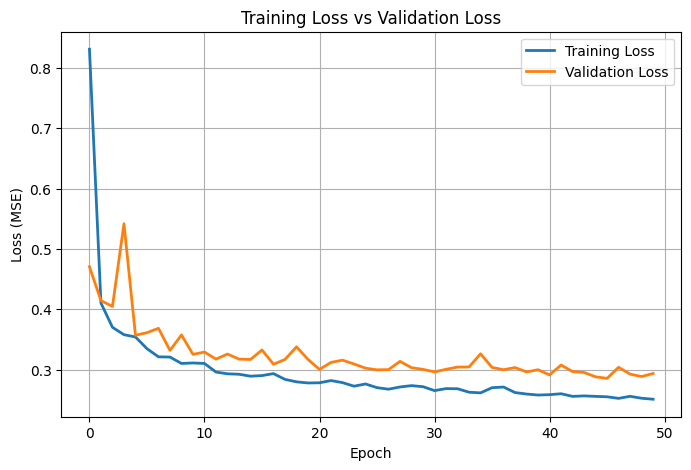

In [ ]:
# Plot Training Loss vs Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2503 - mae: 0.3428 - val_loss: 0.2947 - val_mae: 0.3675
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2499 - mae: 0.3427 - val_loss: 0.2886 - val_mae: 0.3589
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2554 - mae: 0.3431 - val_loss: 0.2989 - val_mae: 0.3774
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2525 - mae: 0.3440 - val_loss: 0.2901 - val_mae: 0.3618
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2493 - mae: 0.3426 - val_loss: 0.3002 - val_mae: 0.3704
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2466 - mae: 0.3410 - val_loss: 0.2973 - val_mae: 0.3598
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2486 - mae: 0.3408 - val_loss: 0.2908 - val_mae: 0.3675
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2477 - mae: 0.3410 - val_loss: 0.2908 - val_mae: 0.3680
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

**Evaluate RMSE, MSE, and MAE**

In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print("Mean Squared Error (MSE):", round(mse, 2))
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Squared Error (MSE): 5.98
Mean Absolute Error (MAE): 2.18
Root Mean Squared Error (RMSE): 2.45
